# 06 - Backtesting V2: mejora operativa del baseline

Este notebook implementa la segunda versión del backtesting de la estrategia DOGE/USDT.

La versión V1 mostró que una señal predictiva aparentemente razonable podía transformarse en un sistema financiero muy frágil cuando se aplicaba directamente sobre el mercado. El problema principal no era únicamente la calidad del modelo, sino la forma de convertir sus probabilidades en decisiones operativas.

La versión V2 mantiene el mismo enfoque predictivo supervisado, pero introduce mejoras operativas sencillas para reducir ruido, exposición y sobreoperación:

- Probabilidades suavizadas mediante media móvil
- Take Profit y Stop Loss dinámicos basados en ATR
- Tamaño de posición limitado
- Cooldown entre operaciones
- Comisiones activas
- Comparación frente a V1 y Buy & Hold

El objetivo de este notebook no es presentar un sistema rentable ni un modelo milagroso. La finalidad es analizar si una capa de gestión operativa más prudente puede reducir el deterioro financiero observado en V1 sin modificar todavía el modelo predictivo.

Esta separación es importante para el TFM: V2 evalúa mejoras de ejecución y gestión de riesgo, no una mejora predictiva del modelo ML.


In [1]:
# ============================================================
# Imports and configuration
# En esta celda se importan las librerías necesarias para el backtesting y se definen los parámetros de la estrategia V2.
# Esta versión mantiene el mismo modelo supervisado que V1, pero añade smoothing de probabilidades, TP/SL basados en ATR, exposición limitada y comisiones activas.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import joblib
from IPython.display import display

# Configuración general del backtest
INITIAL_BALANCE = 1000
TEST_FRACTION = 0.20
FEE_RATE = 0.001          # Comisión por operación: 0.1%

# Trading parameters
PROBA_BUY_THRESHOLD = 0.55
PROBA_SELL_THRESHOLD = 0.45

ATR_MULT_TP = 3.0         # Take Profit dinámico: entrada + 3 ATR
ATR_MULT_SL = 2.0         # Stop Loss dinámico: entrada - 2 ATR

MAX_POSITION_SIZE = 0.50  # Exposición máxima por operación: 50% del capital disponible
COOLDOWN_BARS = 12        # Número de velas de espera tras abrir o cerrar una posición
SMOOTH_WINDOW = 3         # Ventana de suavizado para probabilidades

# Modelo principal seleccionado en el notebook de baseline
MODEL_PATH = Path("../models/xgboost.joblib")
DATA_PATH = Path("../data/processed/DOGEUSDT_5m_binance_2017_2026_features.csv")

# Resultados persistidos entre versiones
RESULTS_DIR = Path("../results")
V1_SUMMARY_PATH = RESULTS_DIR / "05_backtesting_v1_summary.csv"
V1_BACKTEST_PATH = RESULTS_DIR / "05_backtesting_v1_backtest.csv"
V2_SUMMARY_PATH = RESULTS_DIR / "06_backtesting_v2_summary.csv"
V2_BACKTEST_PATH = RESULTS_DIR / "06_backtesting_v2_backtest.csv"


In [2]:
# ============================================================
# Load model and dataset
# Se cargan tanto el dataset enriquecido como el modelo previamente entrenado.
# El objetivo es reutilizar exactamente las mismas features empleadas durante el entrenamiento para evitar inconsistencias entre training, inference y backtesting.
# ============================================================

bundle = joblib.load(MODEL_PATH)

model = bundle["model"]
feature_cols = bundle["feature_cols"]
target = bundle.get("target", "up_1")

df = pd.read_csv(DATA_PATH)

if "open_time" in df.columns:
    df["open_time"] = pd.to_datetime(df["open_time"])

print("Modelo cargado correctamente")
print("Target del modelo:", target)
print("Número de features:", len(feature_cols))
print("Tipo de modelo:", type(model))
print("Shape del dataset:", df.shape)

df.head()


Modelo cargado correctamente
Target del modelo: up_1
Número de features: 40
Tipo de modelo: <class 'xgboost.sklearn.XGBClassifier'>
Shape del dataset: (712257, 54)


,open_time,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,...,price_position_in_recent_range,recent_support,recent_resistance,dist_to_nearest_support,dist_to_nearest_resistance,near_support,near_resistance,support_strength,resistance_strength,touch_count_near_level
0,2019-07-07 11:50:00,0.003496,0.003503,0.003492,0.003492,145316.0,2019-07-07 11:54:59.999,508.053883,14,37501.0,...,0.402795,0.003365,0.00368,0.036312,0.053837,0.0,0.0,30.0,0.0,30.0
1,2019-07-07 11:55:00,0.003494,0.003500,0.003492,0.003500,1727089.0,2019-07-07 11:59:59.999,6040.557436,21,1017415.0,...,0.429479,0.003365,0.00368,0.038624,0.051308,0.0,0.0,30.0,0.0,30.0
2,2019-07-07 12:00:00,0.003497,0.003505,0.003491,0.003505,2644825.0,2019-07-07 12:04:59.999,9268.834500,26,811589.0,...,0.443456,0.003365,0.00368,0.039831,0.049989,0.0,0.0,30.0,0.0,30.0
3,2019-07-07 12:05:00,0.003505,0.003505,0.003487,0.003498,1335881.0,2019-07-07 12:09:59.999,4672.287479,35,1267575.0,...,0.422490,0.003365,0.00368,0.038020,0.051970,0.0,0.0,30.0,0.0,30.0
4,2019-07-07 12:10:00,0.003498,0.003516,0.003498,0.003505,5442392.0,2019-07-07 12:14:59.999,19046.081219,64,5027347.0,...,0.444091,0.003365,0.00368,0.039886,0.049929,0.0,0.0,30.0,0.0,30.0


In [3]:
# ============================================================
# Prepare temporal test set
# El backtesting se realiza exclusivamente sobre el tramo temporal reservado como test.
# Esta separación cronológica evita evaluar la estrategia sobre datos ya vistos por el modelo durante el entrenamiento.
# ============================================================

required_cols = feature_cols + ["close", "atr_14"]

if target in df.columns:
    required_cols.append(target)

df_model = df.dropna(subset=required_cols).copy()

split_index = int(len(df_model) * (1 - TEST_FRACTION))

train_df = df_model.iloc[:split_index].copy()
test_df = df_model.iloc[split_index:].copy()

print("Train rows:", len(train_df))
print("Test rows:", len(test_df))

if "open_time" in test_df.columns:
    print("Periodo de test:")
    print(test_df["open_time"].min(), "->", test_df["open_time"].max())


Train rows: 569805
Test rows: 142452
Periodo de test:
2025-01-13 19:15:00 -> 2026-05-23 10:10:00


In [4]:
# ============================================================
# Generate smoothed model probabilities
# Para trading resulta más útil trabajar con probabilidades que con clases binarias rígidas.
# En V2 las probabilidades se suavizan mediante una media móvil corta para reducir oscilaciones espasmódicas de la señal.
# ============================================================

X_test = test_df[feature_cols]

proba_up_raw = model.predict_proba(X_test)[:, 1]

bt_input = test_df.copy().reset_index(drop=True)
bt_input["proba_up_raw"] = proba_up_raw

bt_input["proba_up_smoothed"] = (
    bt_input["proba_up_raw"]
    .rolling(window=SMOOTH_WINDOW, min_periods=1)
    .mean()
)

bt_input["prediction_v2"] = (
    bt_input["proba_up_smoothed"] >= PROBA_BUY_THRESHOLD
).astype(int)

bt_input[["close", "proba_up_raw", "proba_up_smoothed", "prediction_v2"]].head()


,close,proba_up_raw,proba_up_smoothed,prediction_v2
0,0.32199,0.503449,0.503449,0
1,0.32245,0.481667,0.492558,0
2,0.32380,0.461614,0.482243,0
3,0.32353,0.482750,0.475344,0
4,0.32467,0.452850,0.465738,0


### Comentarios - Probabilidades suavizadas

La versión V2 no opera directamente sobre las probabilidades raw del modelo.

El suavizado mediante una ventana corta reduce parte del ruido producido por cambios rápidos entre señales alcistas y bajistas consecutivas. En velas de 5 minutos, estos cambios pueden generar sobreoperación aunque la diferencia real de confianza sea mínima.

La mejora introducida aquí es operativa, no predictiva:

- El modelo base no cambia
- La señal se procesa antes de convertirse en órdenes
- Se reduce la sensibilidad a fluctuaciones puntuales
- Se intenta evitar que una vela aislada fuerce una operación innecesaria

Este punto diferencia claramente V2 de V1: la primera versión operaba directamente sobre probabilidades raw, mientras que V2 añade una capa sencilla de estabilización de señal.


In [5]:
# ============================================================
# Backtesting engine V2
# Esta función simula una estrategia long-only basada en probabilidades suavizadas del modelo.
# V2 incorpora exposición limitada, comisiones, cooldown y salidas dinámicas mediante ATR para reducir parte de la fragilidad observada en V1.
# ============================================================

def run_backtest_v2(
    df,
    prob_col="proba_up_smoothed",
    price_col="close",
    atr_col="atr_14",
    initial_balance=INITIAL_BALANCE,
    fee_rate=FEE_RATE,
    buy_threshold=PROBA_BUY_THRESHOLD,
    sell_threshold=PROBA_SELL_THRESHOLD,
    atr_mult_tp=ATR_MULT_TP,
    atr_mult_sl=ATR_MULT_SL,
    max_position_size=MAX_POSITION_SIZE,
    cooldown_bars=COOLDOWN_BARS,
):
    df = df.copy().reset_index(drop=True)

    cash = initial_balance
    position = 0.0
    entry_price = None
    tp_price = None
    sl_price = None
    cooldown = 0

    equity_curve = []
    actions = []
    exit_reasons = []
    cash_values = []
    position_values = []
    entry_prices = []
    tp_prices = []
    sl_prices = []

    for _, row in df.iterrows():
        price = row[price_col]
        atr = row[atr_col]
        proba = row[prob_col]

        action = "HOLD"
        exit_reason = None

        if cooldown > 0:
            cooldown -= 1

        # ====================================================
        # Sell logic
        # ====================================================

        if position > 0:
            hit_tp = price >= tp_price
            hit_sl = price <= sl_price
            model_exit = proba <= sell_threshold

            if hit_tp or hit_sl or model_exit:
                cash += position * price * (1 - fee_rate)
                position = 0.0
                entry_price = None
                tp_price = None
                sl_price = None
                cooldown = cooldown_bars
                action = "SELL"

                if hit_tp:
                    exit_reason = "ATR_TP"
                elif hit_sl:
                    exit_reason = "ATR_SL"
                else:
                    exit_reason = "MODEL_EXIT"

        # ====================================================
        # Buy logic
        # ====================================================

        elif cooldown == 0 and proba >= buy_threshold:
            allocation = cash * max_position_size

            position = (allocation * (1 - fee_rate)) / price
            cash -= allocation

            entry_price = price
            tp_price = entry_price + (atr_mult_tp * atr)
            sl_price = entry_price - (atr_mult_sl * atr)

            cooldown = cooldown_bars
            action = "BUY"

        position_value = position * price
        equity = cash + position_value

        equity_curve.append(equity)
        actions.append(action)
        exit_reasons.append(exit_reason)
        cash_values.append(cash)
        position_values.append(position_value)
        entry_prices.append(entry_price)
        tp_prices.append(tp_price)
        sl_prices.append(sl_price)

    df["equity_v2"] = equity_curve
    df["action_v2"] = actions
    df["exit_reason_v2"] = exit_reasons
    df["cash_v2"] = cash_values
    df["position_value_v2"] = position_values
    df["entry_price_v2"] = entry_prices
    df["tp_price_v2"] = tp_prices
    df["sl_price_v2"] = sl_prices

    df["strategy_return_v2"] = df["equity_v2"].pct_change().fillna(0)
    df["equity_cummax_v2"] = df["equity_v2"].cummax()
    df["drawdown_v2"] = (df["equity_v2"] / df["equity_cummax_v2"]) - 1

    return df


## Comentarios - Motor de backtesting V2

El motor V2 representa una evolución operativa del baseline inicial, no una sustitución completa del enfoque del proyecto.

La diferencia principal frente a V1 es que la señal del modelo no se ejecuta de forma tan agresiva. En lugar de invertir todo el capital disponible con TP/SL porcentuales fijos, V2 limita la exposición y adapta las salidas a la volatilidad mediante ATR.

La estrategia incorpora:

- Comisiones por compra y venta
- Tamaño máximo de posición
- Cooldown entre operaciones
- Take Profit dinámico basado en ATR
- Stop Loss dinámico basado en ATR
- Salida por pérdida de confianza del modelo

Aun así, el sistema sigue siendo deliberadamente limitado:

- Continúa siendo long-only
- No incluye slippage
- No utiliza filtros de régimen
- No permite posiciones short
- No optimiza thresholds de forma sistemática
- No cambia el modelo predictivo

Esta separación permite evaluar si la mejora financiera procede de una gestión operativa más prudente, no de una supuesta mejora del modelo ML.


In [6]:
# ============================================================
# Buy and Hold benchmark
# Esta función calcula el rendimiento de una estrategia pasiva Buy & Hold sobre el mismo periodo de test.
# El benchmark compra DOGE al inicio del periodo y mantiene la posición hasta el final, aplicando comisión de entrada para mantener comparabilidad con la estrategia activa.
# ============================================================

def add_buy_and_hold(df, price_col="close", initial_balance=INITIAL_BALANCE, fee_rate=FEE_RATE):
    df = df.copy().reset_index(drop=True)

    first_price = df.loc[0, price_col]
    units = (initial_balance * (1 - fee_rate)) / first_price

    df["buy_hold_equity"] = units * df[price_col]
    df["buy_hold_return"] = df["buy_hold_equity"].pct_change().fillna(0)
    df["buy_hold_cummax"] = df["buy_hold_equity"].cummax()
    df["buy_hold_drawdown"] = (df["buy_hold_equity"] / df["buy_hold_cummax"]) - 1

    return df


In [7]:
# ============================================================
# Load persisted V1 results
# Se cargan los resultados persistidos del notebook 05 para comparar V2 contra el baseline real y no contra valores introducidos manualmente.
# Esta dependencia garantiza trazabilidad entre notebooks y evita que la comparación V1/V2 quede desactualizada.
# ============================================================

def load_v1_results(summary_path=V1_SUMMARY_PATH, backtest_path=V1_BACKTEST_PATH):
    if not summary_path.exists():
        raise FileNotFoundError(
            f"No se encontró {summary_path}. Ejecuta primero la celda final de guardado del notebook 05_backtesting_v1."
        )

    if not backtest_path.exists():
        raise FileNotFoundError(
            f"No se encontró {backtest_path}. Ejecuta primero la celda final de guardado del notebook 05_backtesting_v1."
        )

    v1_summary_df = pd.read_csv(summary_path)
    v1_backtest_df = pd.read_csv(backtest_path)

    required_summary_cols = [
        "final_balance",
        "return_pct",
        "max_drawdown_pct",
        "sharpe_ratio",
        "num_trades",
        "buy_signals",
        "sell_signals",
    ]

    missing_summary_cols = [col for col in required_summary_cols if col not in v1_summary_df.columns]
    if missing_summary_cols:
        raise ValueError(f"Faltan columnas en el summary de V1: {missing_summary_cols}")

    required_backtest_cols = ["equity", "drawdown"]
    missing_backtest_cols = [col for col in required_backtest_cols if col not in v1_backtest_df.columns]
    if missing_backtest_cols:
        raise ValueError(f"Faltan columnas en el backtest detallado de V1: {missing_backtest_cols}")

    return v1_summary_df, v1_backtest_df


v1_summary_df, bt_v1 = load_v1_results()

print("V1 summary loaded from:", V1_SUMMARY_PATH)
print("V1 detailed backtest loaded from:", V1_BACKTEST_PATH)
print("V1 summary shape:", v1_summary_df.shape)
print("V1 backtest shape:", bt_v1.shape)

display(v1_summary_df.head())


V1 summary loaded from: ..\results\05_backtesting_v1_summary.csv
V1 detailed backtest loaded from: ..\results\05_backtesting_v1_backtest.csv
V1 summary shape: (1, 28)
V1 backtest shape: (142452, 69)


,notebook,strategy,initial_balance,final_balance,return_pct,buy_and_hold_final_balance,buy_and_hold_return_pct,max_drawdown_pct,buy_and_hold_max_drawdown_pct,sharpe_ratio,...,position_sizing,max_position_size,probability_handling,tp_sl_method,take_profit_pct,stop_loss_pct,buy_threshold,sell_threshold,cooldown_bars,main_limitation
0,05_backtesting_v1,Long-only supervised model with raw probabilit...,1000,77.777095,-92.22229,308.861921,-69.113808,-92.377242,-81.41076,-4.117639,...,Full exposure,1.0,Raw probabilities,Fixed percentage TP/SL,3.0,2.0,0.55,0.45,12,"Long-only baseline with full exposure, raw pro..."


In [8]:
# ============================================================
# Run backtest V2
# En esta sección se ejecuta la simulación completa de V2 y se añade el benchmark Buy & Hold.
# El resultado es un dataframe con equity, drawdown, acciones, motivos de salida y variables auxiliares para interpretar el comportamiento de la estrategia.
# ============================================================

bt_v2 = run_backtest_v2(bt_input)
bt_v2 = add_buy_and_hold(bt_v2)

display(bt_v2[[
    "close",
    "proba_up_raw",
    "proba_up_smoothed",
    "action_v2",
    "exit_reason_v2",
    "equity_v2",
    "drawdown_v2",
    "buy_hold_equity",
    "buy_hold_drawdown",
]].head())

action_counts_df = (
    bt_v2["action_v2"]
    .value_counts()
    .rename_axis("action")
    .reset_index(name="count")
)

action_counts_df["share_%"] = action_counts_df["count"] / len(bt_v2) * 100

exit_reason_counts_df = (
    bt_v2["exit_reason_v2"]
    .fillna("NO_EXIT")
    .value_counts()
    .rename_axis("exit_reason")
    .reset_index(name="count")
)

exit_reason_counts_df["share_%"] = exit_reason_counts_df["count"] / len(bt_v2) * 100

print("Action counts:")
display(action_counts_df)

print("Exit reason counts:")
display(exit_reason_counts_df)


,close,proba_up_raw,proba_up_smoothed,action_v2,exit_reason_v2,equity_v2,drawdown_v2,buy_hold_equity,buy_hold_drawdown
0,0.32199,0.503449,0.503449,HOLD,None,1000.0,0.0,999.000000,0.000000
1,0.32245,0.481667,0.492558,HOLD,None,1000.0,0.0,1000.427187,0.000000
2,0.32380,0.461614,0.482243,HOLD,None,1000.0,0.0,1004.615671,0.000000
3,0.32353,0.482750,0.475344,HOLD,None,1000.0,0.0,1003.777974,-0.000834
4,0.32467,0.452850,0.465738,HOLD,None,1000.0,0.0,1007.314917,0.000000


Action counts:


,action,count,share_%
0,HOLD,141172,99.101452
1,BUY,640,0.449274
2,SELL,640,0.449274


Exit reason counts:


,exit_reason,count,share_%
0,NO_EXIT,141812,99.550726
1,ATR_SL,360,0.252717
2,ATR_TP,177,0.124252
3,MODEL_EXIT,103,0.072305


### Interpretación inicial del backtest V2

La ejecución del backtest muestra una reducción importante de la actividad operativa frente a V1. El sistema continúa siendo long-only y sigue utilizando el mismo modelo supervisado base, pero las modificaciones operativas introducidas reducen significativamente el ruido y la frecuencia de entrada.

La proporción extremadamente alta de `HOLD` indica que el sistema pasa la mayor parte del tiempo fuera del mercado, evitando reaccionar constantemente a fluctuaciones menores de precio. Esto reduce el efecto acumulativo de fees, disminuye el overtrading y estabiliza parcialmente la evolución de la equity.

Los motivos de salida muestran un predominio claro de `ATR_SL` frente a `ATR_TP`, señal de que el entorno de mercado continúa siendo desfavorable para estrategias long-only. Aun así, el uso de stops dinámicos basados en volatilidad limita pérdidas más agresivas observadas en V1.

En conjunto, los resultados sugieren que la mejora principal de V2 no proviene del modelo predictivo, sino de una gestión operativa más conservadora y adaptativa.


In [9]:
# ============================================================
# Summary metrics and V1 comparison
# Esta sección calcula métricas financieras para comparar V2, V1 real persistido y Buy & Hold de forma compacta.
# La comparación se construye desde los ficheros guardados en results para mantener trazabilidad entre versiones.
# ============================================================

def summarize_strategy_v2(bt):
    final_balance = bt["equity_v2"].iloc[-1]
    total_return = final_balance / INITIAL_BALANCE - 1
    max_drawdown = bt["drawdown_v2"].min()

    num_buys = (bt["action_v2"] == "BUY").sum()
    num_sells = (bt["action_v2"] == "SELL").sum()
    num_trades = num_buys + num_sells
    hold_signals = (bt["action_v2"] == "HOLD").sum()

    returns_std = bt["strategy_return_v2"].std()
    sharpe_approx = (
        bt["strategy_return_v2"].mean() / returns_std * np.sqrt(365 * 24 * 12)
        if returns_std != 0
        else np.nan
    )

    average_exposure = (bt["position_value_v2"] / bt["equity_v2"]).replace([np.inf, -np.inf], np.nan).fillna(0).mean()
    max_exposure = (bt["position_value_v2"] / bt["equity_v2"]).replace([np.inf, -np.inf], np.nan).fillna(0).max()

    return pd.Series({
        "final_balance": final_balance,
        "total_return_%": total_return * 100,
        "max_drawdown_%": max_drawdown * 100,
        "num_trades": num_trades,
        "num_buys": num_buys,
        "num_sells": num_sells,
        "num_holds": hold_signals,
        "sharpe_approx": sharpe_approx,
        "average_exposure_%": average_exposure * 100,
        "max_exposure_%": max_exposure * 100,
    })


def summarize_buy_hold(bt):
    final_balance = bt["buy_hold_equity"].iloc[-1]
    total_return = final_balance / INITIAL_BALANCE - 1
    max_drawdown = bt["buy_hold_drawdown"].min()

    returns_std = bt["buy_hold_return"].std()
    sharpe_approx = (
        bt["buy_hold_return"].mean() / returns_std * np.sqrt(365 * 24 * 12)
        if returns_std != 0
        else np.nan
    )

    return pd.Series({
        "final_balance": final_balance,
        "total_return_%": total_return * 100,
        "max_drawdown_%": max_drawdown * 100,
        "num_trades": 1,
        "num_buys": 1,
        "num_sells": 0,
        "num_holds": np.nan,
        "sharpe_approx": sharpe_approx,
        "average_exposure_%": 100.0,
        "max_exposure_%": 100.0,
    })


def summarize_v1_from_results(v1_summary):
    row = v1_summary.iloc[0]

    return pd.Series({
        "final_balance": row["final_balance"],
        "total_return_%": row["return_pct"],
        "max_drawdown_%": row["max_drawdown_pct"],
        "num_trades": row["num_trades"],
        "num_buys": row["buy_signals"],
        "num_sells": row["sell_signals"],
        "num_holds": row["hold_signals"] if "hold_signals" in v1_summary.columns else np.nan,
        "sharpe_approx": row["sharpe_ratio"],
        "average_exposure_%": np.nan,
        "max_exposure_%": 100.0,
    })


summary = pd.DataFrame({
    "V1 Strategy": summarize_v1_from_results(v1_summary_df),
    "V2 Strategy": summarize_strategy_v2(bt_v2),
    "Buy & Hold": summarize_buy_hold(bt_v2),
}).T

summary["return_improvement_vs_v1_pp"] = summary["total_return_%"] - summary.loc["V1 Strategy", "total_return_%"]
summary["drawdown_improvement_vs_v1_pp"] = summary["max_drawdown_%"] - summary.loc["V1 Strategy", "max_drawdown_%"]

display(summary)


,final_balance,total_return_%,max_drawdown_%,num_trades,num_buys,num_sells,num_holds,sharpe_approx,average_exposure_%,max_exposure_%,return_improvement_vs_v1_pp,drawdown_improvement_vs_v1_pp
V1 Strategy,77.777095,-92.222290,-92.377242,1972.0,986.0,986.0,140480.0,-4.117639,NaN,100.000000,0.000000,0.000000
V2 Strategy,354.512924,-64.548708,-65.912698,1280.0,640.0,640.0,141172.0,-4.483279,5.58965,50.939431,27.673583,26.464544
Buy & Hold,308.861921,-69.113808,-81.410760,1.0,1.0,0.0,NaN,-0.347133,100.00000,100.000000,23.108483,10.966483


In [10]:
# ============================================================
# Numeric comparison tables
# Se generan tablas auxiliares para interpretar rendimiento, drawdown, exposición y operativa sin depender únicamente de las gráficas.
# Estas tablas facilitan la comparación posterior entre V1, V2 y Buy & Hold cuando el notebook se revise con outputs ejecutados.
# ============================================================

performance_comparison_df = summary[[
    "final_balance",
    "total_return_%",
    "max_drawdown_%",
    "sharpe_approx",
    "num_trades",
    "num_buys",
    "num_sells",
    "num_holds",
    "average_exposure_%",
    "max_exposure_%",
    "return_improvement_vs_v1_pp",
    "drawdown_improvement_vs_v1_pp",
]].copy()

display(performance_comparison_df)

v2_operational_summary_df = pd.DataFrame([{
    "initial_balance": INITIAL_BALANCE,
    "final_balance": bt_v2["equity_v2"].iloc[-1],
    "min_equity": bt_v2["equity_v2"].min(),
    "max_equity": bt_v2["equity_v2"].max(),
    "max_drawdown_%": bt_v2["drawdown_v2"].min() * 100,
    "buy_signals": int((bt_v2["action_v2"] == "BUY").sum()),
    "sell_signals": int((bt_v2["action_v2"] == "SELL").sum()),
    "hold_signals": int((bt_v2["action_v2"] == "HOLD").sum()),
    "atr_tp_exits": int((bt_v2["exit_reason_v2"] == "ATR_TP").sum()),
    "atr_sl_exits": int((bt_v2["exit_reason_v2"] == "ATR_SL").sum()),
    "model_exit_exits": int((bt_v2["exit_reason_v2"] == "MODEL_EXIT").sum()),
    "average_exposure_%": (bt_v2["position_value_v2"] / bt_v2["equity_v2"]).replace([np.inf, -np.inf], np.nan).fillna(0).mean() * 100,
    "max_exposure_%": (bt_v2["position_value_v2"] / bt_v2["equity_v2"]).replace([np.inf, -np.inf], np.nan).fillna(0).max() * 100,
}])

display(v2_operational_summary_df)


,final_balance,total_return_%,max_drawdown_%,sharpe_approx,num_trades,num_buys,num_sells,num_holds,average_exposure_%,max_exposure_%,return_improvement_vs_v1_pp,drawdown_improvement_vs_v1_pp
V1 Strategy,77.777095,-92.222290,-92.377242,-4.117639,1972.0,986.0,986.0,140480.0,NaN,100.000000,0.000000,0.000000
V2 Strategy,354.512924,-64.548708,-65.912698,-4.483279,1280.0,640.0,640.0,141172.0,5.58965,50.939431,27.673583,26.464544
Buy & Hold,308.861921,-69.113808,-81.410760,-0.347133,1.0,1.0,0.0,NaN,100.00000,100.000000,23.108483,10.966483


,initial_balance,final_balance,min_equity,max_equity,max_drawdown_%,buy_signals,sell_signals,hold_signals,atr_tp_exits,atr_sl_exits,model_exit_exits,average_exposure_%,max_exposure_%
0,1000,354.512924,349.703262,1025.904792,-65.912698,640,640,141172,177,360,103,5.58965,50.939431


### Interpretación de las métricas agregadas

Las métricas agregadas muestran una mejora material respecto a V1, aunque el sistema continúa siendo incapaz de generar rentabilidad positiva sostenida en el periodo evaluado.

La comparación entre versiones permite distinguir claramente tres niveles:

- V1 representa un baseline operativo extremadamente agresivo y sensible al ruido de mercado
- V2 introduce mecanismos de control operativo que reducen significativamente el deterioro financiero
- Buy & Hold actúa como benchmark pasivo para contextualizar el rendimiento de ambas estrategias

En la ejecución actual, V2 finaliza con 354,51 USDT, frente a los 77,78 USDT de V1 y los 308,86 USDT de Buy & Hold. En términos de retorno, V2 pierde un 64,55 %, pero mejora a V1 en 27,67 puntos porcentuales y supera ligeramente a Buy & Hold en 4,57 puntos porcentuales.

La reducción del número de operaciones y del drawdown confirma que el smoothing de probabilidades, el position sizing limitado y los ATR-based TP/SL consiguen estabilizar parcialmente el comportamiento del sistema. V2 reduce el drawdown máximo hasta aproximadamente el 65,91 %, frente al 92,38 % observado en V1.

El Sharpe ratio continúa siendo negativo, reflejando que el sistema sigue operando sin un edge direccional suficientemente robusto. Sin embargo, las pérdidas se producen de forma más controlada y menos destructiva que en V1.


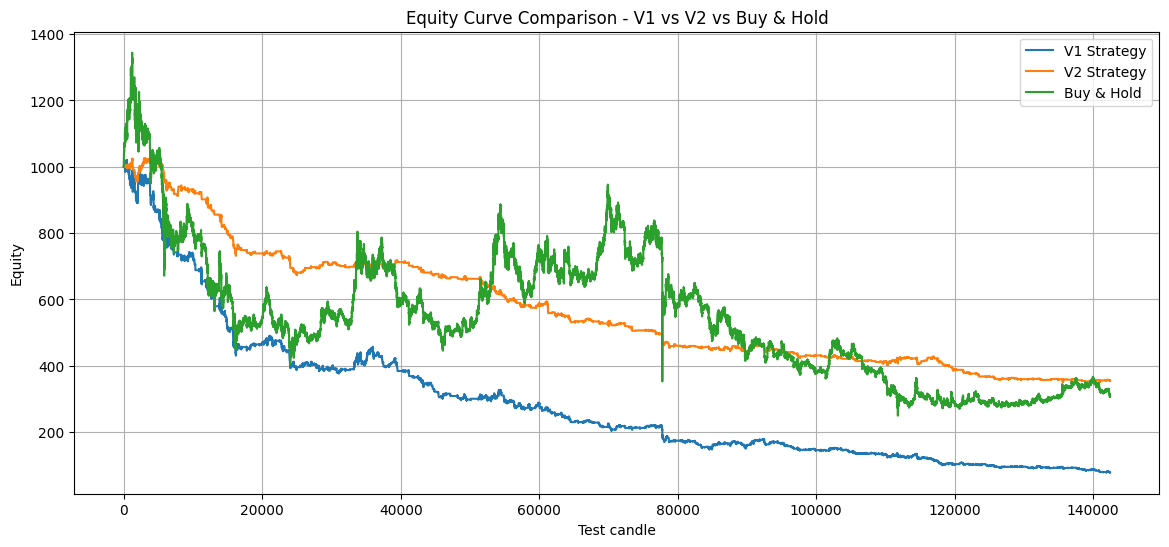

,initial_equity,final_equity,min_equity,max_equity,num_periods,absolute_return,return_%
V1 Strategy,1000.0,77.777095,77.777095,1020.327518,142452.0,-922.222905,-92.222290
V2 Strategy,1000.0,354.512924,349.703262,1025.904792,142452.0,-645.487076,-64.548708
Buy & Hold,999.0,308.861921,249.788782,1343.727756,142452.0,-690.138079,-69.082891


,v1_equity,v2_equity,buy_hold_equity
0,77.777095,354.512924,308.861921
1,77.777095,354.512924,308.954999
2,77.777095,354.512924,308.613715
3,77.777095,354.512924,308.613715
4,77.777095,354.512924,308.737818
5,77.777095,354.512924,308.582689
6,77.777095,354.512924,308.396534
7,77.777095,354.512924,308.458586
8,77.777095,354.512924,308.582689
9,77.777095,354.512924,308.861921


In [11]:
# ============================================================
# Equity curve comparison
# Esta visualización compara la evolución temporal del capital de V2 frente a V1 real persistido y Buy & Hold.
# La comparación usa la curva detallada de V1 guardada en results para evitar referencias manuales y mantener trazabilidad entre notebooks.
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    bt_v1["equity"].values,
    label="V1 Strategy"
)

plt.plot(
    bt_v2["equity_v2"].values,
    label="V2 Strategy"
)

plt.plot(
    bt_v2["buy_hold_equity"].values,
    label="Buy & Hold"
)

plt.legend()
plt.title("Equity Curve Comparison - V1 vs V2 vs Buy & Hold")
plt.xlabel("Test candle")
plt.ylabel("Equity")
plt.grid(True)
plt.show()

equity_curve_summary_df = pd.DataFrame({
    "V1 Strategy": {
        "initial_equity": bt_v1["equity"].iloc[0],
        "final_equity": bt_v1["equity"].iloc[-1],
        "min_equity": bt_v1["equity"].min(),
        "max_equity": bt_v1["equity"].max(),
        "num_periods": len(bt_v1),
    },
    "V2 Strategy": {
        "initial_equity": bt_v2["equity_v2"].iloc[0],
        "final_equity": bt_v2["equity_v2"].iloc[-1],
        "min_equity": bt_v2["equity_v2"].min(),
        "max_equity": bt_v2["equity_v2"].max(),
        "num_periods": len(bt_v2),
    },
    "Buy & Hold": {
        "initial_equity": bt_v2["buy_hold_equity"].iloc[0],
        "final_equity": bt_v2["buy_hold_equity"].iloc[-1],
        "min_equity": bt_v2["buy_hold_equity"].min(),
        "max_equity": bt_v2["buy_hold_equity"].max(),
        "num_periods": len(bt_v2),
    },
}).T

equity_curve_summary_df["absolute_return"] = equity_curve_summary_df["final_equity"] - equity_curve_summary_df["initial_equity"]
equity_curve_summary_df["return_%"] = (equity_curve_summary_df["final_equity"] / equity_curve_summary_df["initial_equity"] - 1) * 100

display(equity_curve_summary_df)

equity_tail_df = pd.DataFrame({
    "v1_equity": bt_v1["equity"].tail(10).reset_index(drop=True),
    "v2_equity": bt_v2["equity_v2"].tail(10).reset_index(drop=True),
    "buy_hold_equity": bt_v2["buy_hold_equity"].tail(10).reset_index(drop=True),
})

display(equity_tail_df)


### Interpretación de la curva de equity

La curva de equity de V2 muestra un comportamiento considerablemente más estable que el observado en V1. Aunque la tendencia general continúa siendo bajista, el deterioro del capital es más gradual y menos explosivo.

La comparación visual entre V1, V2 y Buy & Hold sugiere que las mejoras operativas reducen parcialmente el impacto de las fases más agresivas de caída del mercado. La equity deja de presentar movimientos extremadamente erráticos y pasa a reflejar una exposición más controlada.

La reducción de la pendiente negativa respecto a V1 indica que el sistema evita parte del deterioro causado anteriormente por el exceso de operaciones y por la exposición constante al mercado.

Aun así, la curva continúa mostrando ausencia de crecimiento sostenido, lo que sugiere que la robustez operativa mejora la supervivencia del sistema, pero todavía no compensa completamente la falta de capacidad predictiva en un entorno bajista.


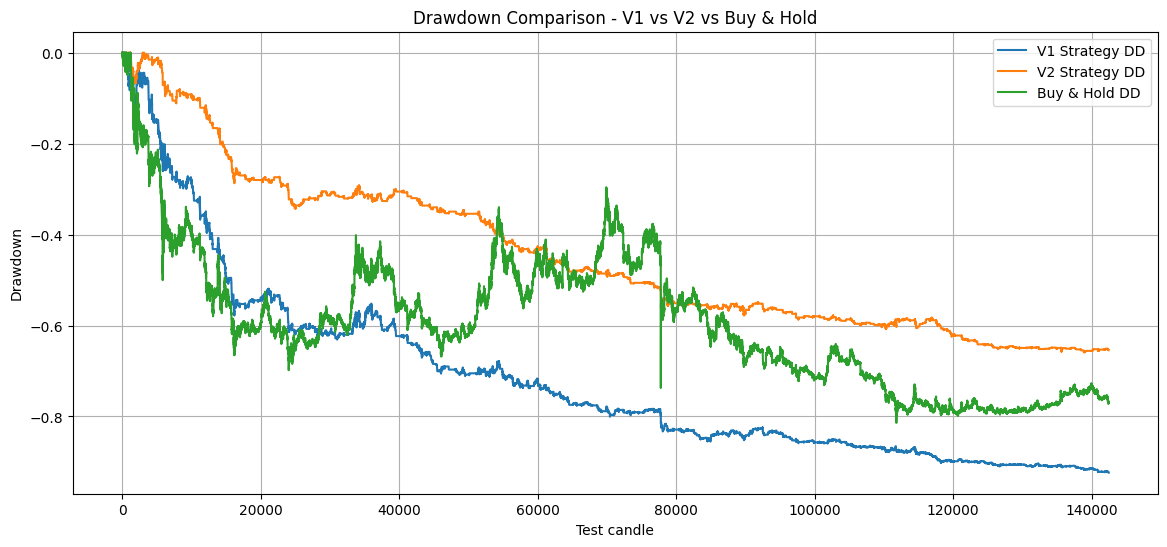

,max_drawdown_%,final_drawdown_%,periods_below_-10%,periods_below_-25%,periods_below_-50%
V1 Strategy,-92.377242,-92.377242,138902.0,135720.0,126966.0
V2 Strategy,-65.912698,-65.443877,132465.0,126634.0,69094.0
Buy & Hold,-81.410760,-77.014546,140807.0,137392.0,104737.0


In [12]:
# ============================================================
# Drawdown comparison
# Esta visualización compara el drawdown de V2 frente a V1 real persistido y Buy & Hold.
# El objetivo es comprobar si la capa operativa reduce las pérdidas desde máximos frente al baseline agresivo y frente a una exposición pasiva continua.
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    bt_v1["drawdown"].values,
    label="V1 Strategy DD"
)

plt.plot(
    bt_v2["drawdown_v2"].values,
    label="V2 Strategy DD"
)

plt.plot(
    bt_v2["buy_hold_drawdown"].values,
    label="Buy & Hold DD"
)

plt.legend()
plt.title("Drawdown Comparison - V1 vs V2 vs Buy & Hold")
plt.xlabel("Test candle")
plt.ylabel("Drawdown")
plt.grid(True)
plt.show()

drawdown_summary_df = pd.DataFrame({
    "V1 Strategy": {
        "max_drawdown_%": bt_v1["drawdown"].min() * 100,
        "final_drawdown_%": bt_v1["drawdown"].iloc[-1] * 100,
        "periods_below_-10%": int((bt_v1["drawdown"] <= -0.10).sum()),
        "periods_below_-25%": int((bt_v1["drawdown"] <= -0.25).sum()),
        "periods_below_-50%": int((bt_v1["drawdown"] <= -0.50).sum()),
    },
    "V2 Strategy": {
        "max_drawdown_%": bt_v2["drawdown_v2"].min() * 100,
        "final_drawdown_%": bt_v2["drawdown_v2"].iloc[-1] * 100,
        "periods_below_-10%": int((bt_v2["drawdown_v2"] <= -0.10).sum()),
        "periods_below_-25%": int((bt_v2["drawdown_v2"] <= -0.25).sum()),
        "periods_below_-50%": int((bt_v2["drawdown_v2"] <= -0.50).sum()),
    },
    "Buy & Hold": {
        "max_drawdown_%": bt_v2["buy_hold_drawdown"].min() * 100,
        "final_drawdown_%": bt_v2["buy_hold_drawdown"].iloc[-1] * 100,
        "periods_below_-10%": int((bt_v2["buy_hold_drawdown"] <= -0.10).sum()),
        "periods_below_-25%": int((bt_v2["buy_hold_drawdown"] <= -0.25).sum()),
        "periods_below_-50%": int((bt_v2["buy_hold_drawdown"] <= -0.50).sum()),
    },
}).T

display(drawdown_summary_df)


### Interpretación del drawdown

El drawdown máximo de V2 se reduce de forma significativa respecto a V1, indicando una mejora clara en el control de exposición y en la gestión del riesgo operativo.

Mientras que V1 sufría una destrucción casi total del capital debido a la combinación de full exposure, probabilidades raw y sobreoperación, V2 limita parcialmente ese deterioro mediante una operativa más selectiva y adaptativa a volatilidad.

La comparación frente a Buy & Hold también resulta relevante. Aunque V2 sigue siendo una estrategia perdedora en términos absolutos, consigue amortiguar parte de las caídas más severas del mercado y presenta un drawdown máximo menor que el benchmark pasivo.

Esto refuerza la idea de que los mecanismos operativos de V2 aportan robustez financiera incluso sin modificar el modelo supervisado subyacente.

Sin embargo, un drawdown menor no implica necesariamente una estrategia rentable. El sistema continúa operando sin una ventaja direccional suficientemente fuerte, por lo que la mejora observada debe interpretarse como una reducción del deterioro y no como una resolución completa del problema de trading.


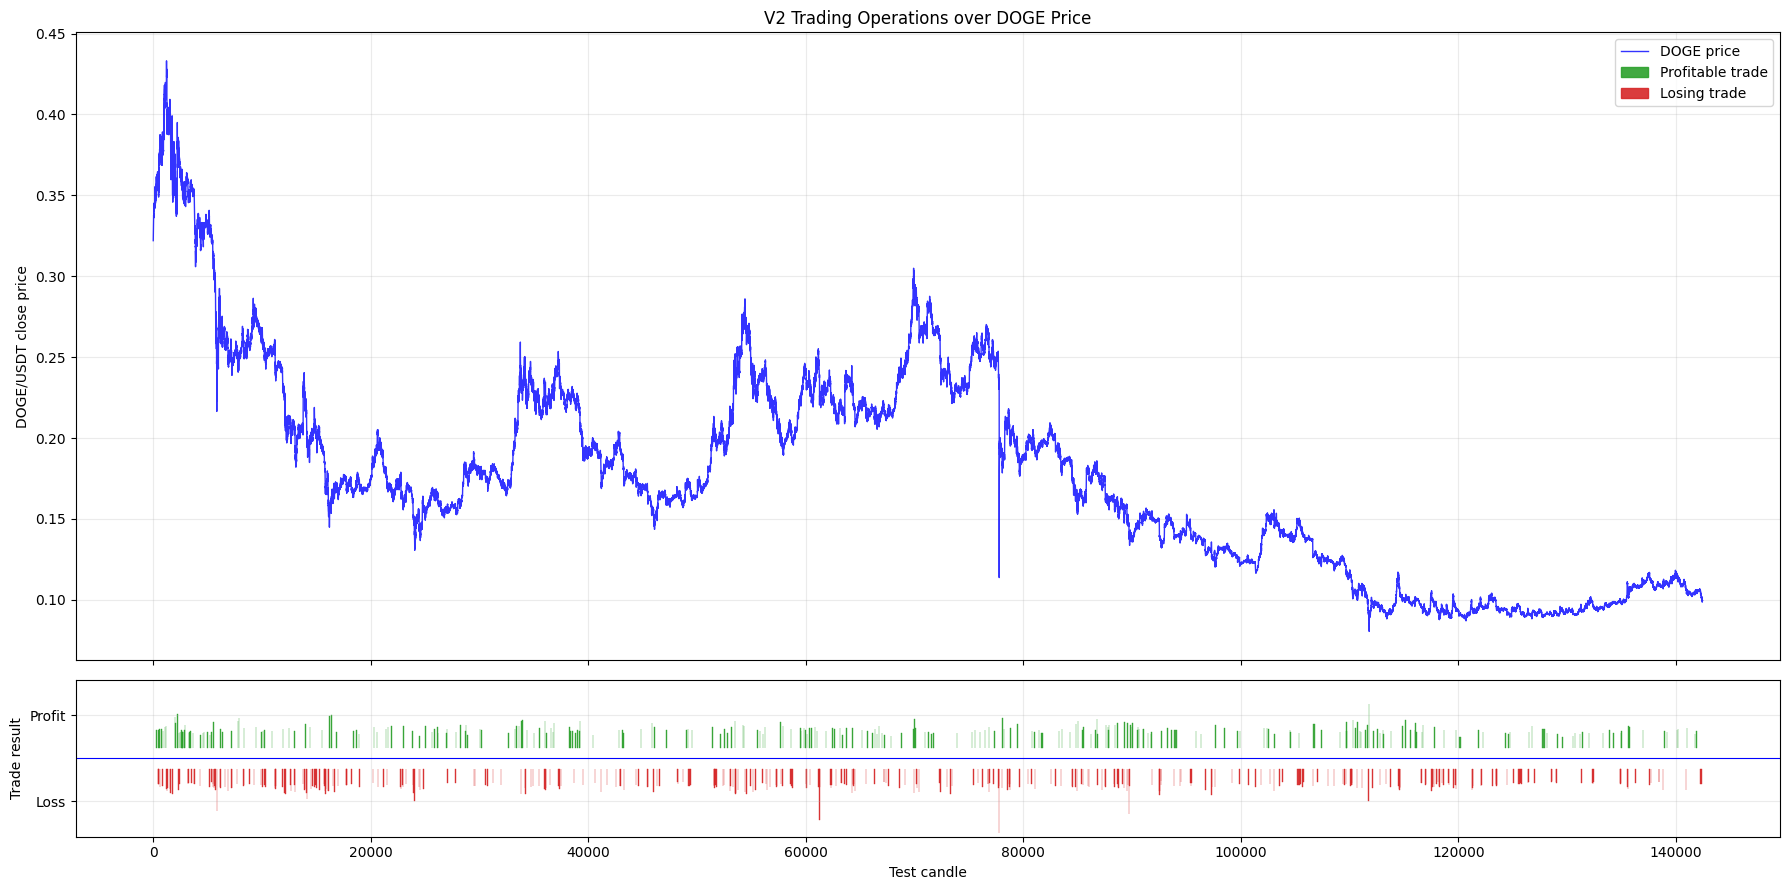

First V2 trade events:


,close,proba_up_raw,proba_up_smoothed,action_v2,exit_reason_v2,equity_v2,drawdown_v2,cash_v2,position_value_v2,entry_price_v2,tp_price_v2,sl_price_v2
299,0.35308,0.541079,0.550691,BUY,None,999.500000,-0.000500,500.000000,499.500000,0.35308,0.356789,0.350607
309,0.35714,0.464126,0.467779,SELL,ATR_TP,1004.738412,0.000000,1004.738412,0.000000,NaN,NaN,NaN
460,0.35582,0.576113,0.558214,BUY,None,1004.236043,-0.000500,502.369206,501.866837,0.35582,0.359386,0.353443
463,0.35317,0.584996,0.578838,SELL,ATR_SL,1000.000217,-0.004931,1000.000217,0.000000,NaN,NaN,NaN
477,0.35307,0.566330,0.561579,BUY,None,999.500217,-0.005428,500.000109,499.500109,0.35307,0.356025,0.351100
480,0.35052,0.522822,0.533551,SELL,ATR_SL,995.396753,-0.009511,995.396753,0.000000,NaN,NaN,NaN
492,0.34918,0.587578,0.564955,BUY,None,994.899055,-0.010007,497.698377,497.200678,0.34918,0.353215,0.346490
501,0.35363,0.464096,0.496484,SELL,ATR_TP,1000.731915,-0.004203,1000.731915,0.000000,NaN,NaN,NaN
560,0.36854,0.557804,0.552973,BUY,None,1000.231549,-0.004701,500.365957,499.865591,0.36854,0.372890,0.365640
569,0.37358,0.469087,0.495587,SELL,ATR_TP,1006.560801,0.000000,1006.560801,0.000000,NaN,NaN,NaN


Last V2 trade events:


,close,proba_up_raw,proba_up_smoothed,action_v2,exit_reason_v2,equity_v2,drawdown_v2,cash_v2,position_value_v2,entry_price_v2,tp_price_v2,sl_price_v2
140977,0.10392,0.568854,0.554981,BUY,None,353.200703,-0.655718,176.688696,176.512007,0.10392,0.105107,0.103129
141029,0.10562,0.394317,0.449371,SELL,ATR_TP,355.908817,-0.653078,355.908817,0.000000,NaN,NaN,NaN
141732,0.10306,0.557145,0.553852,BUY,None,355.730862,-0.653252,177.954408,177.776454,0.10306,0.103634,0.102677
141750,0.10365,0.443765,0.479747,SELL,ATR_TP,356.569807,-0.652434,356.569807,0.000000,NaN,NaN,NaN
141878,0.10441,0.606129,0.553432,BUY,None,356.391522,-0.652608,178.284903,178.106618,0.10441,0.105164,0.103907
141960,0.10544,0.459972,0.471027,SELL,ATR_TP,357.968672,-0.651070,357.968672,0.000000,NaN,NaN,NaN
142266,0.10401,0.566404,0.556644,BUY,None,357.789687,-0.651245,178.984336,178.805352,0.10401,0.105131,0.103263
142275,0.10322,0.531932,0.527551,SELL,ATR_SL,356.254138,-0.652742,356.254138,0.000000,NaN,NaN,NaN
142332,0.10139,0.577995,0.564668,BUY,None,356.076011,-0.652915,178.127069,177.948942,0.10139,0.102566,0.100606
142410,0.10060,0.534644,0.536568,SELL,ATR_SL,354.512924,-0.654439,354.512924,0.000000,NaN,NaN,NaN


Completed V2 trades:


,entry_idx,exit_idx,entry_price,exit_price,pnl_pct,duration_bars,exit_reason_v2,result
0,299,309,0.35308,0.35714,1.149881,10,ATR_TP,PROFIT
1,460,463,0.35582,0.35317,-0.744759,3,ATR_SL,LOSS
2,477,480,0.35307,0.35052,-0.722236,3,ATR_SL,LOSS
3,492,501,0.34918,0.35363,1.274414,9,ATR_TP,PROFIT
4,560,569,0.36854,0.37358,1.367558,9,ATR_TP,PROFIT
...,...,...,...,...,...,...,...,...
635,140977,141029,0.10392,0.10562,1.635874,52,ATR_TP,PROFIT
636,141732,141750,0.10306,0.10365,0.572482,18,ATR_TP,PROFIT
637,141878,141960,0.10441,0.10544,0.986496,82,ATR_TP,PROFIT
638,142266,142275,0.10401,0.10322,-0.759542,9,ATR_SL,LOSS


,num_test_candles,num_trade_events,trade_event_share_%,num_buy_events,num_sell_events,num_hold_events,num_completed_trades,profitable_trades,losing_trades,win_rate_%,avg_trade_pnl_%,median_trade_pnl_%,avg_trade_duration_bars,avg_candles_per_trade_event
0,142452,1280,0.898548,640,640,141172,640,280,360,43.75,-0.118232,-0.628323,24.876562,111.290625


In [13]:
# ============================================================
# Trading operations timeline
# Esta visualización muestra las operaciones completas ejecutadas por V2 usando un panel de precio y un panel de resultados operativos.
# También se muestran tablas de operaciones y salidas para analizar frecuencia operativa, exposición y motivos de cierre sin depender solo del gráfico.
# ============================================================

import matplotlib.patches as patches

plot_df = bt_v2.copy().reset_index(drop=True)

trade_rows = []

position_open = False
entry_idx = None
entry_price = None

for i, row in plot_df.iterrows():
    action = row["action_v2"]
    price_i = float(row["close"])

    if action == "BUY" and not position_open:
        position_open = True
        entry_idx = i
        entry_price = price_i

    elif action == "SELL" and position_open:
        exit_idx = i
        exit_price = price_i

        pnl_pct = (exit_price / entry_price - 1) * 100

        trade_rows.append({
            "entry_idx": entry_idx,
            "exit_idx": exit_idx,
            "entry_price": entry_price,
            "exit_price": exit_price,
            "pnl_pct": pnl_pct,
            "duration_bars": exit_idx - entry_idx,
            "exit_reason_v2": row.get("exit_reason_v2", None),
            "result": "PROFIT" if pnl_pct >= 0 else "LOSS"
        })

        position_open = False
        entry_idx = None
        entry_price = None

trades_v2_df = pd.DataFrame(trade_rows)

price = plot_df["close"].astype(float).reset_index(drop=True)
x = np.arange(len(price))

fig, (ax_price, ax_trades) = plt.subplots(
    2,
    1,
    figsize=(18, 9),
    sharex=True,
    gridspec_kw={"height_ratios": [4, 1]}
)

# ============================================================
# Price series
# ============================================================

ax_price.plot(
    x,
    price,
    color="blue",
    linewidth=1.0,
    alpha=0.8,
    label="DOGE price"
)

ax_price.set_title("V2 Trading Operations over DOGE Price")
ax_price.set_ylabel("DOGE/USDT close price")
ax_price.grid(alpha=0.25)

# ============================================================
# Trade activity blocks
# ============================================================

if not trades_v2_df.empty:

    max_abs_pnl = max(trades_v2_df["pnl_pct"].abs().max(), 1e-9)

    for _, trade in trades_v2_df.iterrows():

        entry_idx = int(trade["entry_idx"])
        exit_idx = int(trade["exit_idx"])

        actual_width = max(exit_idx - entry_idx, 1)
        visual_width = max(actual_width, 45)

        x_start = entry_idx - (visual_width - actual_width) / 2

        pnl_scaled = abs(trade["pnl_pct"]) / max_abs_pnl
        height = 0.15 + pnl_scaled * 0.75

        if trade["result"] == "PROFIT":
            y_base = 0.15
            color = "tab:green"
            label = "Profitable trade"

        else:
            y_base = -0.15 - height
            color = "tab:red"
            label = "Losing trade"

        rect = patches.Rectangle(
            (x_start, y_base),
            visual_width,
            height,
            linewidth=0.3,
            edgecolor=color,
            facecolor=color,
            alpha=0.9
        )

        ax_trades.add_patch(rect)

ax_trades.axhline(0, color="blue", linewidth=0.8)

ax_trades.set_ylim(-1.1, 1.1)

ax_trades.set_ylabel("Trade result")
ax_trades.set_xlabel("Test candle")

ax_trades.set_yticks([-0.6, 0.6])
ax_trades.set_yticklabels(["Loss", "Profit"])

ax_trades.grid(alpha=0.25)

legend_handles = [
    patches.Patch(facecolor="tab:green", edgecolor="tab:green", alpha=0.9, label="Profitable trade"),
    patches.Patch(facecolor="tab:red", edgecolor="tab:red", alpha=0.9, label="Losing trade"),
]

ax_price.legend(
    handles=[ax_price.get_legend_handles_labels()[0][0]] + legend_handles,
    loc="upper right"
)

plt.tight_layout()
plt.show()

# ============================================================
# Trade events and activity summaries
# ============================================================

trade_events_v2_df = bt_v2.loc[
    bt_v2["action_v2"].isin(["BUY", "SELL"]),
    [
        "close",
        "proba_up_raw",
        "proba_up_smoothed",
        "action_v2",
        "exit_reason_v2",
        "equity_v2",
        "drawdown_v2",
        "cash_v2",
        "position_value_v2",
        "entry_price_v2",
        "tp_price_v2",
        "sl_price_v2",
    ]
].copy()

print("First V2 trade events:")
display(trade_events_v2_df.head(10))

print("Last V2 trade events:")
display(trade_events_v2_df.tail(10))

print("Completed V2 trades:")
display(trades_v2_df)

trade_frequency_summary_df = pd.DataFrame([{
    "num_test_candles": len(bt_v2),
    "num_trade_events": len(trade_events_v2_df),
    "trade_event_share_%": len(trade_events_v2_df) / len(bt_v2) * 100,
    "num_buy_events": int((bt_v2["action_v2"] == "BUY").sum()),
    "num_sell_events": int((bt_v2["action_v2"] == "SELL").sum()),
    "num_hold_events": int((bt_v2["action_v2"] == "HOLD").sum()),
    "num_completed_trades": len(trades_v2_df),
    "profitable_trades": int((trades_v2_df["pnl_pct"] >= 0).sum()) if len(trades_v2_df) > 0 else 0,
    "losing_trades": int((trades_v2_df["pnl_pct"] < 0).sum()) if len(trades_v2_df) > 0 else 0,
    "win_rate_%": (trades_v2_df["pnl_pct"] >= 0).mean() * 100 if len(trades_v2_df) > 0 else np.nan,
    "avg_trade_pnl_%": trades_v2_df["pnl_pct"].mean() if len(trades_v2_df) > 0 else np.nan,
    "median_trade_pnl_%": trades_v2_df["pnl_pct"].median() if len(trades_v2_df) > 0 else np.nan,
    "avg_trade_duration_bars": trades_v2_df["duration_bars"].mean() if len(trades_v2_df) > 0 else np.nan,
    "avg_candles_per_trade_event": len(bt_v2) / len(trade_events_v2_df) if len(trade_events_v2_df) > 0 else np.nan,
}])

display(trade_frequency_summary_df)

### Interpretación de las operaciones sobre el precio

La distribución de operaciones sobre el gráfico de precio muestra una reducción visible de la sobreoperación observada en V1.

Las entradas aparecen más espaciadas temporalmente y existe una menor concentración de operaciones consecutivas en zonas de ruido o lateralidad extrema. Esto sugiere que el smoothing de probabilidades y las restricciones de exposición filtran parte de las señales menos fiables.

La duración media de las posiciones también parece aumentar respecto a V1, indicando que el sistema deja de reaccionar constantemente a fluctuaciones menores de corto plazo.

Aun así, siguen observándose múltiples entradas long durante fases bajistas prolongadas, lo que refleja que el modelo mantiene un sesgo alcista importante y todavía carece de mecanismos explícitos de adaptación al régimen de mercado.

Esta limitación justifica la evolución planteada para V3, donde se introducirán filtros de régimen, shorts simulados y lógica operativa más cercana a condiciones reales.


In [14]:
# ============================================================
# Save V2 backtesting results
# Se guardan el resumen comparable de V2 y el backtest detallado para reutilizar estos resultados en V3 y en la memoria del TFM.
# También se guardan tablas auxiliares de comparación para facilitar la trazabilidad entre versiones.
# ============================================================

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

results_summary = {
    "notebook": "06_backtesting_v2",
    "strategy": "Long-only supervised model with probability smoothing, ATR-based TP/SL and limited exposure",
    "initial_balance": INITIAL_BALANCE,
    "final_balance": summary.loc["V2 Strategy", "final_balance"],
    "return_pct": summary.loc["V2 Strategy", "total_return_%"],
    "buy_and_hold_final_balance": summary.loc["Buy & Hold", "final_balance"],
    "buy_and_hold_return_pct": summary.loc["Buy & Hold", "total_return_%"],
    "v1_final_balance": summary.loc["V1 Strategy", "final_balance"],
    "v1_return_pct": summary.loc["V1 Strategy", "total_return_%"],
    "max_drawdown_pct": summary.loc["V2 Strategy", "max_drawdown_%"],
    "buy_and_hold_max_drawdown_pct": summary.loc["Buy & Hold", "max_drawdown_%"],
    "v1_max_drawdown_pct": summary.loc["V1 Strategy", "max_drawdown_%"],
    "sharpe_ratio": summary.loc["V2 Strategy", "sharpe_approx"],
    "buy_and_hold_sharpe_ratio": summary.loc["Buy & Hold", "sharpe_approx"],
    "v1_sharpe_ratio": summary.loc["V1 Strategy", "sharpe_approx"],
    "num_trades": int(summary.loc["V2 Strategy", "num_trades"]),
    "buy_signals": int(summary.loc["V2 Strategy", "num_buys"]),
    "sell_signals": int(summary.loc["V2 Strategy", "num_sells"]),
    "hold_signals": int(summary.loc["V2 Strategy", "num_holds"]),
    "fees_applied": True,
    "fee_rate": FEE_RATE,
    "slippage_applied": False,
    "position_sizing": "Limited exposure",
    "max_position_size": MAX_POSITION_SIZE,
    "average_exposure_pct": summary.loc["V2 Strategy", "average_exposure_%"],
    "max_exposure_pct": summary.loc["V2 Strategy", "max_exposure_%"],
    "probability_handling": "Smoothed probabilities",
    "smoothing_window": SMOOTH_WINDOW,
    "tp_sl_method": "ATR-based TP/SL",
    "atr_mult_tp": ATR_MULT_TP,
    "atr_mult_sl": ATR_MULT_SL,
    "buy_threshold": PROBA_BUY_THRESHOLD,
    "sell_threshold": PROBA_SELL_THRESHOLD,
    "cooldown_bars": COOLDOWN_BARS,
    "return_improvement_vs_v1_pp": summary.loc["V2 Strategy", "return_improvement_vs_v1_pp"],
    "drawdown_improvement_vs_v1_pp": summary.loc["V2 Strategy", "drawdown_improvement_vs_v1_pp"],
    "main_limitation": "Long-only strategy without slippage, regime filters, short positions or systematic threshold tuning"
}

results_summary_df = pd.DataFrame([results_summary])

results_summary_df.to_csv(V2_SUMMARY_PATH, index=False)
bt_v2.to_csv(V2_BACKTEST_PATH, index=False)

performance_comparison_df.to_csv(RESULTS_DIR / "06_backtesting_v2_comparison.csv", index=True)
v2_operational_summary_df.to_csv(RESULTS_DIR / "06_backtesting_v2_operational_summary.csv", index=False)

print(f"Summary saved to: {V2_SUMMARY_PATH}")
print(f"Detailed backtest saved to: {V2_BACKTEST_PATH}")
print(f"Comparison table saved to: {RESULTS_DIR / '06_backtesting_v2_comparison.csv'}")
print(f"Operational summary saved to: {RESULTS_DIR / '06_backtesting_v2_operational_summary.csv'}")

display(results_summary_df)


Summary saved to: ..\results\06_backtesting_v2_summary.csv
Detailed backtest saved to: ..\results\06_backtesting_v2_backtest.csv
Comparison table saved to: ..\results\06_backtesting_v2_comparison.csv
Operational summary saved to: ..\results\06_backtesting_v2_operational_summary.csv


,notebook,strategy,initial_balance,final_balance,return_pct,buy_and_hold_final_balance,buy_and_hold_return_pct,v1_final_balance,v1_return_pct,max_drawdown_pct,...,smoothing_window,tp_sl_method,atr_mult_tp,atr_mult_sl,buy_threshold,sell_threshold,cooldown_bars,return_improvement_vs_v1_pp,drawdown_improvement_vs_v1_pp,main_limitation
0,06_backtesting_v2,Long-only supervised model with probability sm...,1000,354.512924,-64.548708,308.861921,-69.113808,77.777095,-92.22229,-65.912698,...,3,ATR-based TP/SL,3.0,2.0,0.55,0.45,12,27.673583,26.464544,"Long-only strategy without slippage, regime fi..."


# Conclusión

Este notebook representa una segunda evolución del sistema de backtesting, centrada no en modificar el modelo supervisado base, sino en mejorar la gestión operativa de las decisiones de trading.

Los resultados muestran que mecanismos relativamente simples como el smoothing de probabilidades, el position sizing limitado y los ATR-based TP/SL reducen de forma importante el deterioro financiero observado en V1.

La mejora principal de V2 no proviene de una mayor capacidad predictiva, sino de:

- Reducción del ruido operativo
- Menor exposición constante al mercado
- Disminución del overtrading
- Adaptación parcial a la volatilidad
- Gestión de riesgo más conservadora

Aunque la estrategia continúa siendo perdedora en términos absolutos, V2 conserva significativamente más capital que V1. El balance final pasa de 77,78 USDT en V1 a 354,51 USDT en V2, y el drawdown máximo se reduce aproximadamente desde el 92,38 % hasta el 65,91 %.

La comparación frente a Buy & Hold también es relevante: V2 supera ligeramente al benchmark pasivo durante el periodo evaluado, aunque ambos resultados siguen siendo negativos. Esta mejora no prueba la existencia de una ventaja predictiva sólida, pero sí muestra que la ingeniería operativa puede aportar robustez financiera cuando el modelo de partida es débil.

Al mismo tiempo, las limitaciones observadas indican que el sistema sigue teniendo dificultades importantes para adaptarse a mercados persistentemente bajistas, especialmente debido a:

- Sesgo long-only
- Ausencia de regime filters
- Falta de shorts
- Dependencia de señales supervisadas relativamente débiles

Estas limitaciones justifican la siguiente evolución del proyecto en V3, donde se introducirán mecanismos de adaptación al régimen de mercado y un backtesting más cercano a condiciones reales.
